In [42]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix
import lime
import lime.lime_text
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score

# Importing Dataset

In [3]:
x_train = pd.read_csv('X_train_NLP_1.csv')
x_test = pd.read_csv('X_test_NLP_1.csv')
x_val = pd.read_csv('X_val_NLP_1.csv')

In [4]:
y_train = pd.read_csv('y_train_NLP_1.csv')
y_test = pd.read_csv('y_test_NLP_1.csv')
y_val = pd.read_csv('y_val_NLP_1.csv')

In [5]:
x_train.head()

,clean_tweet,tweet_length,num_hashtags,lexicon_score
0,donated diesel fuel thought freedom convoy gof...,250,0,2
1,called freedom convoy gone look u let talk say...,165,0,1
2,called freedom convoy consequence related poli...,136,0,0
3,freedom convoy preemptive so press conference ...,112,0,1
4,day freedom convoy still strong ottawa rebel news,81,0,2


#  Converting y to 3 categories

In [6]:
def label_sentiment(score):
    if score in [0, 1]:  # e.g., most negative
        return 0  # Negative
    elif score == 2:     # neutral middle point
        return 1  # Neutral
    else:                # 3, 4 -> more positive
        return 2

y_train['y_class'] = y_train['label'].apply(label_sentiment)


In [7]:
y_test['y_class'] = y_test['label'].apply(label_sentiment)
y_val['y_class'] = y_val['label'].apply(label_sentiment)

In [28]:
y_train.nunique()

label      5
y_class    3
dtype: int64

In [9]:
print(y_train['label'].value_counts())
print(y_train['label'].unique())

label
4    140220
2     46209
1     38402
3     25533
0     20434
Name: count, dtype: int64
[4 2 0 1 3]


In [10]:

x_train['clean_tweet'] = x_train['clean_tweet'].fillna('').astype(str)
x_val['clean_tweet'] = x_val['clean_tweet'].fillna('').astype(str)
x_test['clean_tweet'] = x_test['clean_tweet'].fillna('').astype(str)

# Convert y_train, y_val, y_test to numpy arrays if they are DataFrames/Series

y_train_arr = y_train['y_class'].values
y_val_arr = y_val['y_class'].values
y_test_arr = y_test['y_class'].values

In [11]:
vocab_size = 10000 # Max number of words to keep based on frequency
embedding_dim = 100 # Dimension for the word embeddings
max_sequence_length = 100 # Max length for input sequencess

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<unk>")
tokenizer.fit_on_texts(x_train['clean_tweet'])

word_index = tokenizer.word_index
print(f"Found {len(word_index)} unique tokens after fitting on x_train.")

# Convert text to sequences and pad for all datasets
X_train_padded_text = pad_sequences(tokenizer.texts_to_sequences(x_train['clean_tweet']),
                                    maxlen=max_sequence_length, padding='post', truncating='post')
X_val_padded_text = pad_sequences(tokenizer.texts_to_sequences(x_val['clean_tweet']),
                                  maxlen=max_sequence_length, padding='post', truncating='post')
X_test_padded_text = pad_sequences(tokenizer.texts_to_sequences(x_test['clean_tweet']),
                                   maxlen=max_sequence_length, padding='post', truncating='post')

X_train_raw_text = x_train['clean_tweet'].values
X_val_raw_text = x_val['clean_tweet'].values
X_test_raw_text = x_test['clean_tweet'].values

Found 76222 unique tokens after fitting on x_train.


In [12]:
X_train_numerical = x_train[['tweet_length', 'num_hashtags', 'lexicon_score']].values
X_val_numerical = x_val[['tweet_length', 'num_hashtags', 'lexicon_score']].values
X_test_numerical = x_test[['tweet_length', 'num_hashtags', 'lexicon_score']].values

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_numerical_scaled = scaler.fit_transform(X_train_numerical)
X_val_numerical_scaled = scaler.transform(X_val_numerical)
X_test_numerical_scaled = scaler.transform(X_test_numerical)

In [13]:
num_classes = len(np.unique(y_train_arr)) 

In [14]:
print(num_classes)

3


In [15]:
model_text_only = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_sequence_length),
    Bidirectional(GRU(64, return_sequences=True)), # First GRU layer, returns sequences for next GRU
    Dropout(0.3),
    Bidirectional(GRU(32)), # Second GRU layer, returns a single vector
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax') # Softmax for multi-class classification
])

model_text_only.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_text_only.summary()



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 100, 100)          1000000   
                                                                 
 bidirectional (Bidirection  (None, 100, 128)          63744     
 al)                                                             
                                                                 
 dropout (Dropout)           (None, 100, 128)          0         
                                                                 
 bidirectional_1 (Bidirecti  (None, 64)                31104     
 onal)                                                           
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense (Dense)               (None, 64)               

#  Training model with early stopping 

In [16]:
start_time = time.time()
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Choose the model you want to train (model_text_only or model_multi_input)
# If using text-only model:
model_to_train = model_text_only
X_train_for_fit = X_train_padded_text
X_val_for_fit = X_val_padded_text



print("\nStarting model training...")
history = model_to_train.fit(
    X_train_for_fit, y_train_arr,
    epochs=5, # Set a reasonably high number of epochs; EarlyStopping will manage
    batch_size=32,
    validation_data=(X_val_for_fit, y_val_arr),
    callbacks=[early_stopping],
    verbose=1
)
print("Model training finished.")


Starting model training...
Epoch 1/2


8463/8463 [==============================] - 1537s 181ms/step - loss: 0.6627 - accuracy: 0.7310 - val_loss: 0.5798 - val_accuracy: 0.7677
Epoch 2/2
8463/8463 [==============================] - 1111s 131ms/step - loss: 0.5489 - accuracy: 0.7847 - val_loss: 0.5437 - val_accuracy: 0.7847
Model training finished.


In [ ]:
end_time = time.time()
training_time_seconds = end_time - start_time
print(f"Training Time = {training_time_seconds:.2f} seconds")

#  Test accuracy 

In [17]:
if model_to_train == model_text_only:
    X_test_for_eval = X_test_padded_text
else:
    X_test_for_eval = [X_test_padded_text, X_test_numerical_scaled]

loss, accuracy = model_to_train.evaluate(X_test_for_eval, y_test_arr, verbose=0)
print(f"\n--- Model Evaluation on Test Set ---")
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")


--- Model Evaluation on Test Set ---
Test Loss: 0.5422
Test Accuracy: 0.7862


2821/2821 [==============================] - 107s 37ms/step

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.69      0.54      0.60     19612
           1       0.85      0.57      0.68     15403
           2       0.80      0.94      0.86     55252

    accuracy                           0.79     90267
   macro avg       0.78      0.68      0.72     90267
weighted avg       0.78      0.79      0.77     90267


--- Confusion Matrix ---


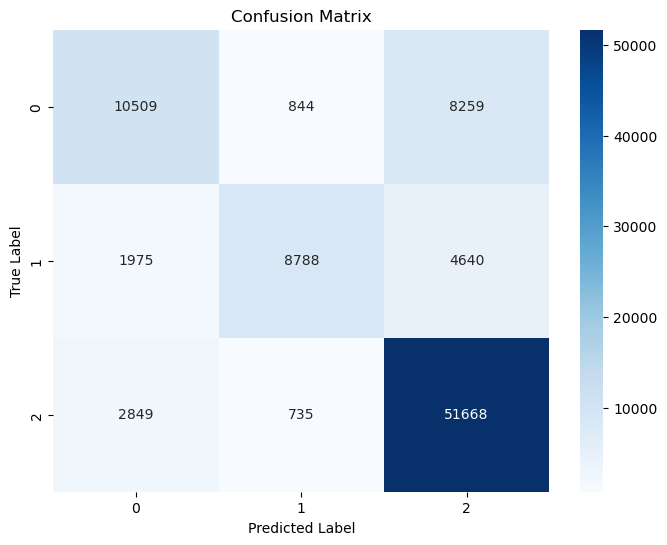

In [18]:
y_pred_probs = model_to_train.predict(X_test_for_eval)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

print("\n--- Classification Report ---")
print(classification_report(y_test_arr, y_pred_classes))

print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_test_arr, y_pred_classes)
plt.figure(figsize=(8, 6))
# Ensure xticklabels and yticklabels match your actual class labels
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y_train_arr), yticklabels=np.unique(y_train_arr))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [51]:
y_test_labels = np.argmax(y_test, axis=1)

In [ ]:
y_pred_probs = model_to_train.predict(X_test_for_eval)

In [40]:
auc_score = roc_auc_score(y_test_arr, y_pred_probs, multi_class='ovr', average='macro')
print(f"Multiclass AUC (macro average, One-vs-Rest): {auc_score:.4f}")

Multiclass AUC (macro average, One-vs-Rest): 0.8907


In [54]:
f1_macro = f1_score(y_test_labels, y_pred_classes, average='macro')
f1_micro = f1_score(y_test_labels, y_pred_classes, average='micro')
print(f"F1 Score (Macro): {f1_macro:.4f}")
print(f"F1 Score (Micro): {f1_micro:.4f}")

F1 Score (Macro): 0.0968
F1 Score (Micro): 0.1699


In [56]:
from tensorflow.keras.utils import to_categorical

num_classes = 3  # total classes in your classification problem
y_test_onehot = to_categorical(y_test_labels, num_classes=num_classes)

# LIME (feature importance)

In [19]:
# This function adapts for text-only or multi-input model
def predict_proba_for_lime(texts):
    # 1. Tokenize and pad the input texts
    sequences = tokenizer.texts_to_sequences(texts)
    padded_sequences = pad_sequences(sequences, maxlen=max_sequence_length, padding='post', truncating='post')

    
    if model_to_train.name == 'model_multi_input': # Check if it's the multi-input model
        num_features_placeholder = np.zeros((len(texts), X_test_numerical_scaled.shape[1]))
        
        return model_to_train.predict([padded_sequences, num_features_placeholder])
    else: # Text-only model
        return model_to_train.predict(padded_sequences)

explainer_lime = lime.lime_text.LimeTextExplainer(
    class_names=[str(c) for c in np.unique(y_train_arr)], # Use unique class labels from y_train
    split_expression=' ', 
    random_state=42
)


idx_to_explain = 0 # Choose an index from your test set (e.g., 0 to X_test_raw_text.shape[0]-1)

text_to_explain = X_test_raw_text[idx_to_explain]
true_label = y_test_arr[idx_to_explain]
predicted_label_probs = model_to_train.predict(X_test_for_eval[idx_to_explain:idx_to_explain+1] if isinstance(X_test_for_eval, list) else X_test_for_eval[idx_to_explain:idx_to_explain+1])
predicted_label_idx = np.argmax(predicted_label_probs, axis=1)[0]
predicted_label_idx = np.argmax(predicted_label_probs, axis=1)[5]


print(f"\n--- LIME Explanation for Test Sample at Index {idx_to_explain} ---")
print(f"Original Text: '{text_to_explain}'")
print(f"True Label: {true_label}")
print(f"Predicted Label: {predicted_label_idx}")

explanation_lime = explainer_lime.explain_instance(
    text_to_explain,
    predict_proba_for_lime,
    num_features=10, # Number of most important words to display
    num_samples=1000 # Number of perturbed samples for explanation (higher is more accurate, but slower)
)

print("\nWord importance (LIME) for this prediction:")
for word, weight in explanation_lime.as_list():
    print(f"  '{word}': {weight:.4f}")



1/1 [==============================] - 0s 65ms/step

--- LIME Explanation for Test Sample at Index 0 ---
Original Text: 'opp head defends comment freedom convoy national security threat'
True Label: 0
Predicted Label: 0
32/32 [==============================] - 1s 42ms/step

Word importance (LIME) for this prediction:
  'freedom': -0.1854
  'defends': 0.0366
  'convoy': -0.0178
  'national': -0.0178
  'head': -0.0167
  'opp': -0.0167
  'security': 0.0163
  'threat': 0.0076
  'comment': -0.0030
